# Activity 2: Analyzing Different Scenarios and Generating the Appropriate Visualization

We'll be working with the 120 years of Olympic History dataset acquired by Randi Griffin from https://www.sports-reference.com/ and made available on the GitHub repository of this book. Your assignment is to identify the top five sports based on the largest number of medals awarded in the year 2016, and then perform the following analysis:

1.  Generate a plot indicating the number of medals awarded in each of the top five sports in 2016.
2.  Plot a graph depicting the distribution of the age of medal winners in the top five sports in 2016.
3.  Find out which national teams won the largest number of medals in the top five sports in 2016.
4.  Observe the trend in the average weight of male and female athletes winning in the top five sports in 2016.

## High-Level Steps

1.  Download the dataset and format it as a pandas DataFrame.
2.  Filter the DataFrame to only include the rows corresponding to medal winners from 2016.
3.  Find out the medals awarded in 2016 for each sport.
4.  List the top five sports based on the largest number of medals awarded. Filter the DataFrame one more time to only include the records for the top five sports in 2016.
5.  Generate a bar plot of record counts corresponding to each of the top five sports.
6.  Generate a histogram for the Age feature of all medal winners in the top five sports (2016).
7.  Generate a bar plot indicating how many medals were won by each country's team in the top five sports in 2016.
8.  Generate a bar plot indicating the average weight of players, categorized based on gender, winning in the top five sports in 2016.

Les 5 sports avec le plus de médailles en 2016 : ['Athletics', 'Swimming', 'Rowing', 'Football', 'Hockey']


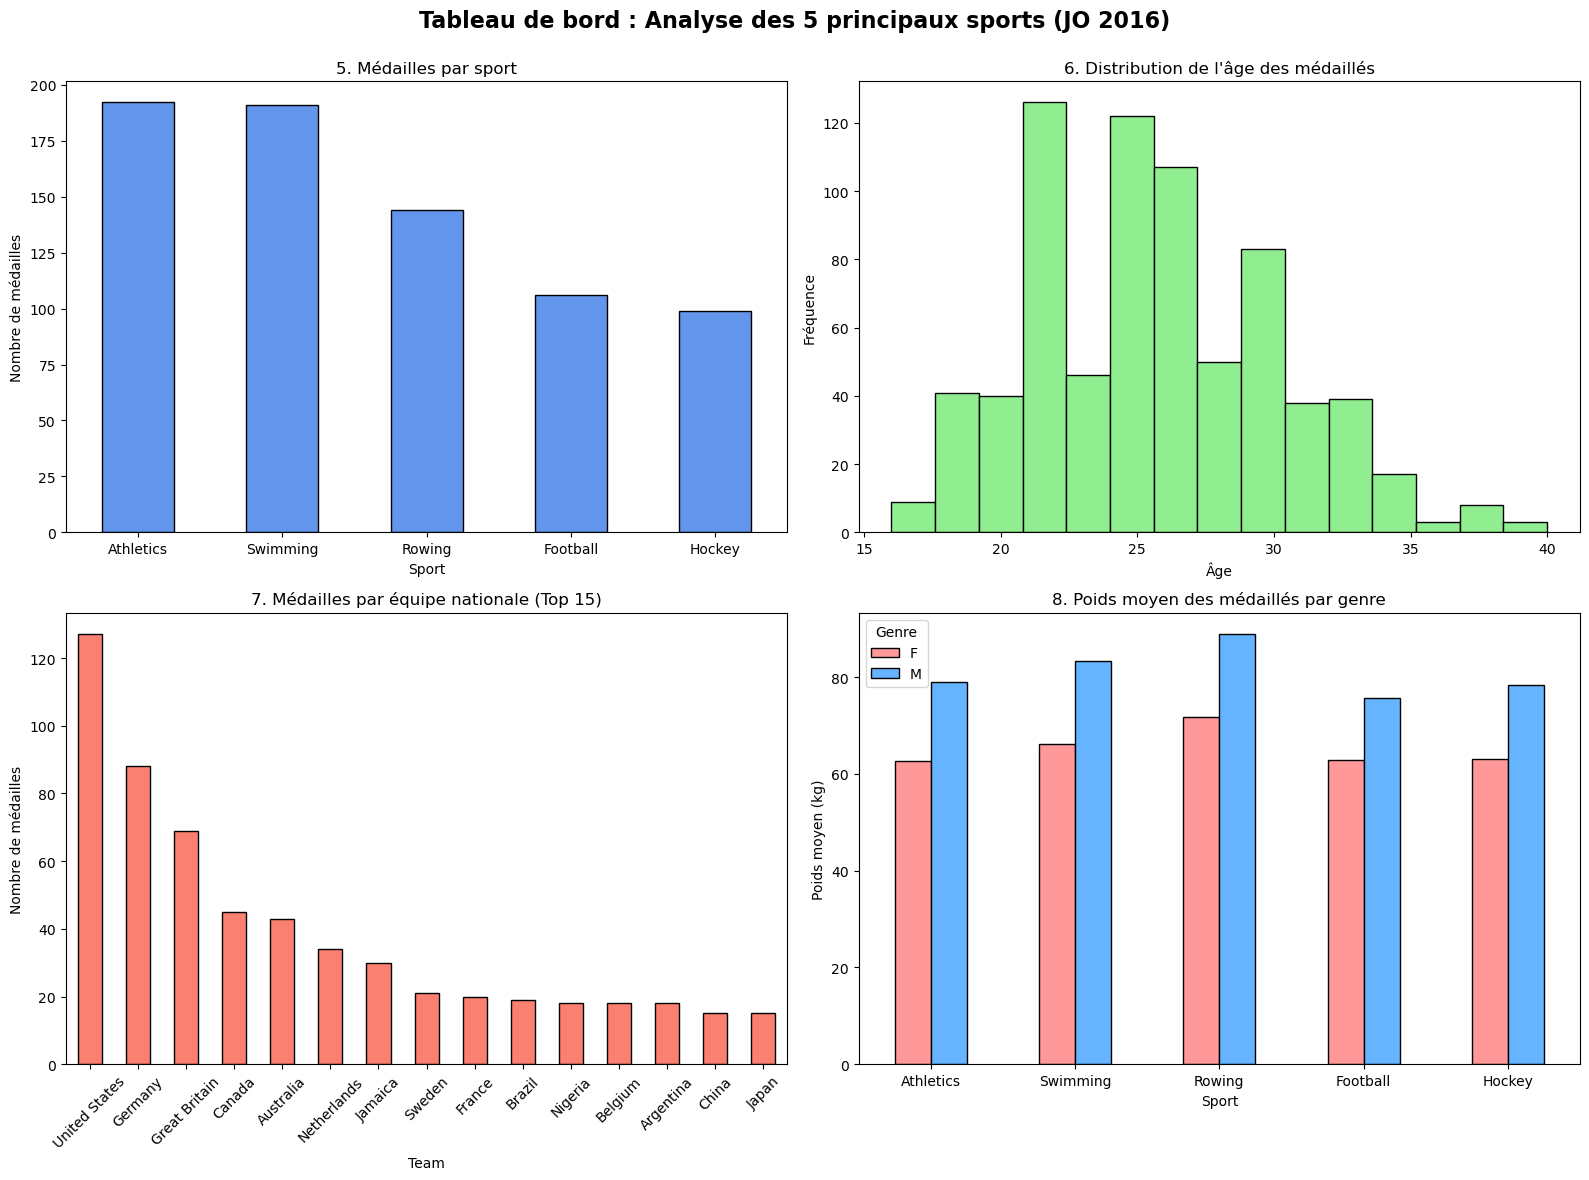

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------------
# 1. Chargement des données
# ---------------------------------------------------------------------------------
url = "https://raw.githubusercontent.com/rgriff23/Olympic_history/master/data/athlete_events.csv"
df = pd.read_csv(url)

# ---------------------------------------------------------------------------------
# 2. Filtrage pour 2016 et uniquement les gagnants de médailles (via .query)
# ---------------------------------------------------------------------------------
df_2016_medals = df.query("Year == 2016 and Medal.notnull()").copy()

# ---------------------------------------------------------------------------------
# 3 & 4. Identification des 5 sports principaux et filtrage final
# ---------------------------------------------------------------------------------
# value_counts() compte les occurrences et trie automatiquement par ordre décroissant
top_5_sports = df_2016_medals['Sport'].value_counts().nlargest(5).index.tolist()

print("Les 5 sports avec le plus de médailles en 2016 :", top_5_sports)

# Filtrage du DataFrame pour ne garder que ces 5 sports
df_top5 = df_2016_medals.query("Sport in @top_5_sports")

# ---------------------------------------------------------------------------------
# Préparation d'une figure unique contenant 4 sous-graphiques (2 lignes, 2 colonnes)
# ---------------------------------------------------------------------------------
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle("Tableau de bord : Analyse des 5 principaux sports (JO 2016)", fontsize=16, fontweight='bold')

# --- Graphique 1 (Haut Gauche) : Nombre de médailles par sport ---
df_top5['Sport'].value_counts().loc[top_5_sports].plot(
    kind='bar', ax=axes[0, 0], color='cornflowerblue', edgecolor='black'
)
axes[0, 0].set_title("5. Médailles par sport")
axes[0, 0].set_ylabel("Nombre de médailles")
axes[0, 0].tick_params(axis='x', rotation=0)

# --- Graphique 2 (Haut Droite) : Distribution de l'âge ---
df_top5['Age'].plot(
    kind='hist', bins=15, ax=axes[0, 1], color='lightgreen', edgecolor='black'
)
axes[0, 1].set_title("6. Distribution de l'âge des médaillés")
axes[0, 1].set_xlabel("Âge")
axes[0, 1].set_ylabel("Fréquence")

# --- Graphique 3 (Bas Gauche) : Médailles par équipe nationale (Top 15) ---
df_top5['Team'].value_counts().head(15).plot(
    kind='bar', ax=axes[1, 0], color='salmon', edgecolor='black'
)
axes[1, 0].set_title("7. Médailles par équipe nationale (Top 15)")
axes[1, 0].set_ylabel("Nombre de médailles")
axes[1, 0].tick_params(axis='x', rotation=45)

# --- Graphique 4 (Bas Droite) : Poids moyen par sport et genre ---
# Création d'un tableau croisé dynamique pour préparer les données avant le tracé
pivot_weight = df_top5.pivot_table(index='Sport', columns='Sex', values='Weight', aggfunc='mean')
pivot_weight.loc[top_5_sports].plot(
    kind='bar', ax=axes[1, 1], color=['#ff9999', '#66b3ff'], edgecolor='black'
)
axes[1, 1].set_title("8. Poids moyen des médaillés par genre")
axes[1, 1].set_ylabel("Poids moyen (kg)")
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend(title='Genre')

# Ajustement de la mise en page pour éviter que les éléments ne se chevauchent
plt.tight_layout()
plt.subplots_adjust(top=0.92) # Laisse un peu de place pour le titre principal
plt.show()